In [5]:
# Reload magics
%load_ext autoreload
%autoreload 2

from gs.core.GaussianModel import GaussianModel
from gs.eval import eval_views
from gs.io.colmap import load

if __name__ == "__main__":
    cameras, sparse = load("./datasets/mip_nerf_360/treehill/")
    grid_model = GaussianModel.from_ply("./samples/treehill_grid_bench.ply").cuda()
    basic_model = GaussianModel.from_ply("./samples/treehill_basic_bench.ply").cuda()
    grid_eval = eval_views(cameras, grid_model)
    basic_eval = eval_views(cameras, basic_model)
    

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


100%|██████████| 141/141 [00:15<00:00,  9.09it/s]


In [6]:
grid_eval.mean()

camera    70.000000
psnr      20.650752
ssim       0.612725
lpips      0.423490
dtype: float64

In [7]:
basic_eval.mean()

camera    70.000000
psnr      21.344813
ssim       0.644685
lpips      0.387463
dtype: float64

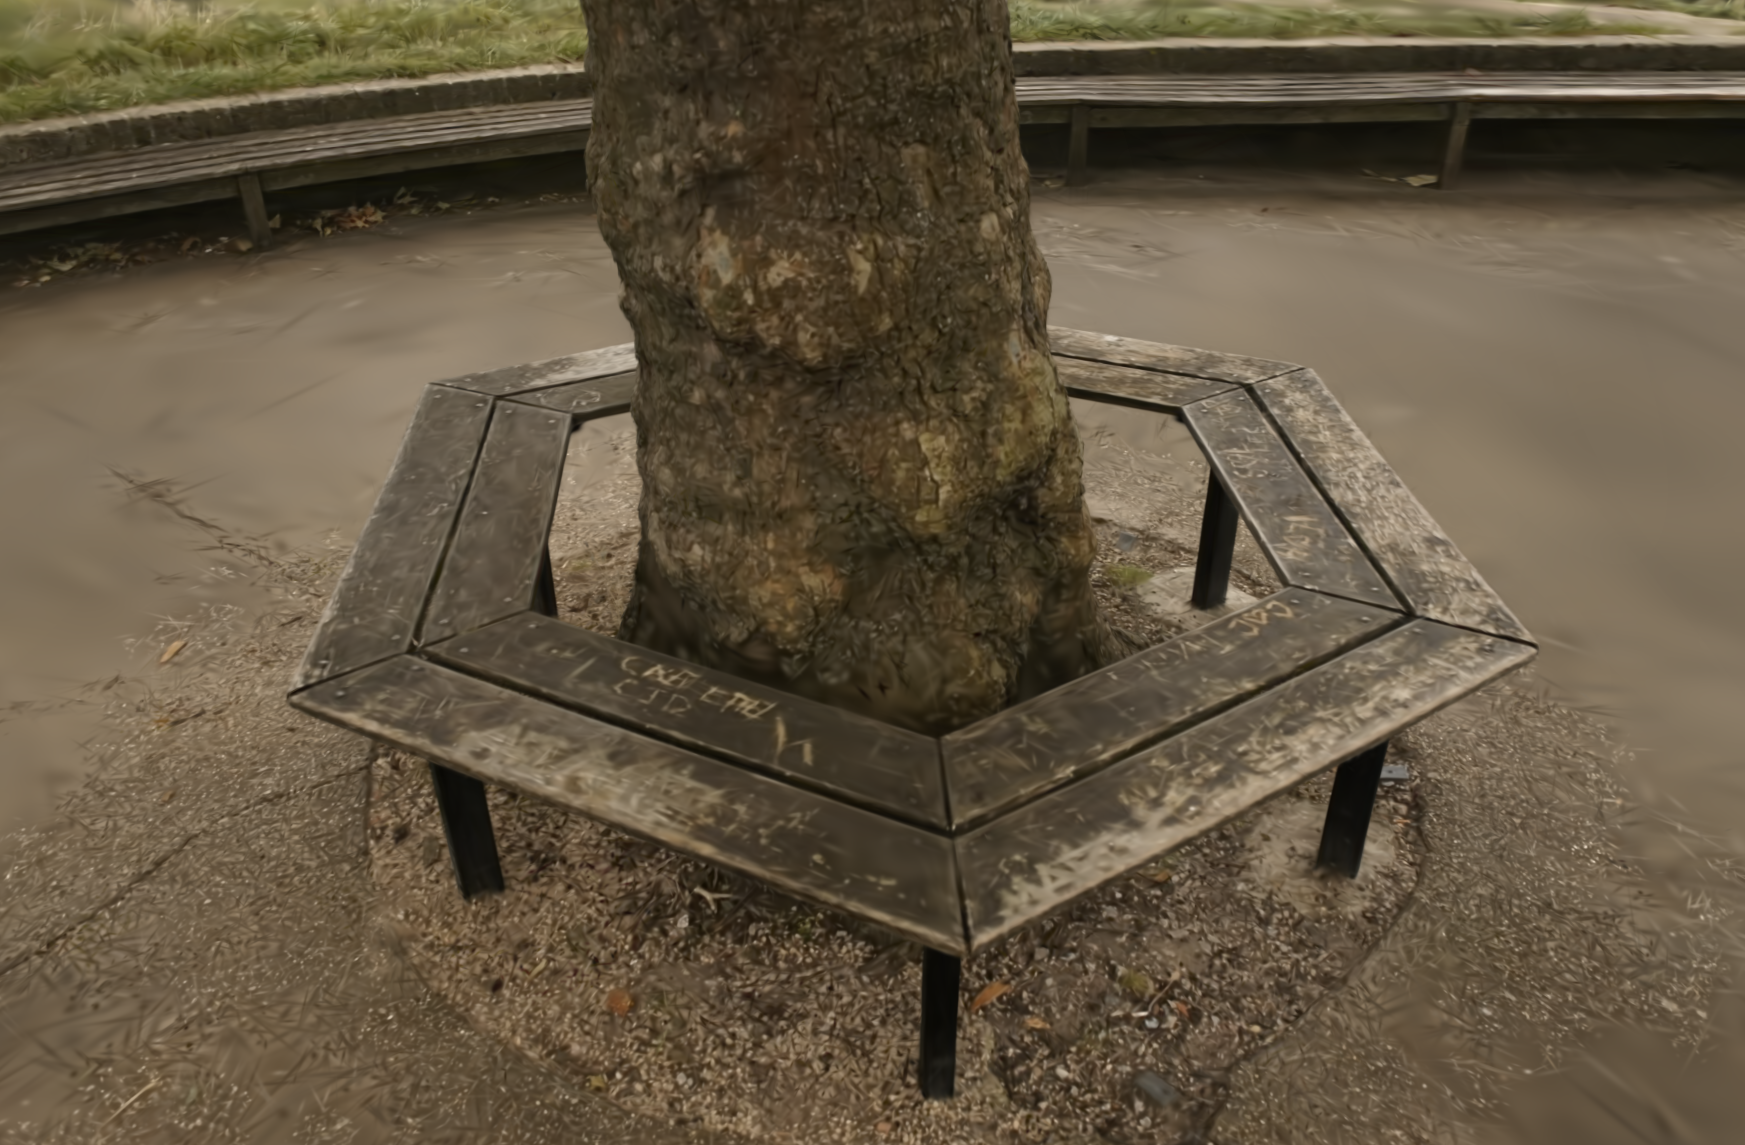

In [14]:
import torch
from gs.helpers.image import torch_to_pil

with torch.no_grad():
    display(torch_to_pil(basic_model.forward(cameras[132])[0].cpu()))